In [ ]:
# mapping
# figure_restoration_potential_wetland_maps.ipynb

[INFO] Reading wetlands GeoPackage:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386 features.
[INFO] Wetlands CRS: EPSG:5070
[INFO] Reading per-wetland probabilities (wide):
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability rows (wide): 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] High-priority wetlands (P(UAI > 0) > 0.75): 24245 of 135204 (17.9%).
[INFO] Computing 2D Gaussian KDE…
[INFO] Evaluating KDE on grid…
[INFO] Plotting KDE heatmap.
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_

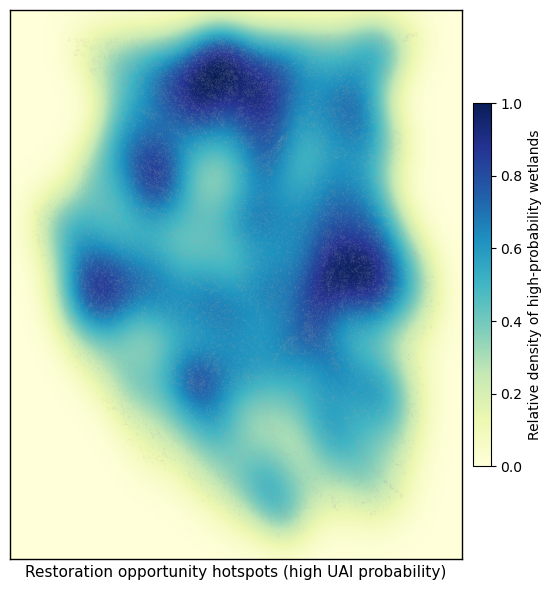

In [2]:
#!/usr/bin/env python3
# uai_highprob_kde_map.py
#
# Kernel-density “blueprint” map of high-priority restoration wetlands:
# wetlands with long-term P(UAI > 0) above a given threshold (default 0.75).
#
# Author: Kimberly Van Meter

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands GeoPackage (already in EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide format)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

# Output figures
OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint.png"
OUT_JPG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the per-wetland CSV

# Column with P(UAI > 0) in the wide CSV
PROB_COL = "p_gt_0.000"

# High-priority threshold
HIGH_PROB_THRESH = 0.75

# KDE grid resolution
NX = 300
NY = 300

# Bandwidth multiplier for KDE (1.0 = default, >1 smoother, <1 sharper)
BANDWIDTH_MULT = 1.0

# Colormap for heatmap
CMAP = "YlGnBu"  # "blueprint" style restoration opportunity


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # 1. Read wetland polygons
    print(f"[INFO] Reading wetlands GeoPackage:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GeoPackage. "
            f"Available columns: {list(gdf.columns)}"
        )

    print(f"[INFO] Wetland polygons loaded: {len(gdf)} features.")
    print(f"[INFO] Wetlands CRS: {gdf.crs}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities (wide):\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability rows (wide): {len(prob_df)}")

    # 3. Merge GPKG with probabilities: Index (GPKG) ↔ label (CSV)
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )
    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    if merged.empty:
        raise ValueError(
            "Merge produced zero rows. Check ID_COL_GPKG / ID_COL_CSV and inputs."
        )

    # 4. Filter to high-priority wetlands
    high = merged[merged[PROB_COL] > HIGH_PROB_THRESH].copy()
    n_high = len(high)
    n_total = len(merged)
    if n_high == 0:
        raise ValueError(
            f"No wetlands found with {PROB_COL} > {HIGH_PROB_THRESH}. "
            "Check thresholds and data."
        )

    pct_high = 100.0 * n_high / n_total
    print(
        f"[INFO] High-priority wetlands (P(UAI > 0) > {HIGH_PROB_THRESH}): "
        f"{n_high} of {n_total} ({pct_high:.1f}%)."
    )

    # 5. Ensure projected CRS (use EPSG:5070, which your GPKG already uses)
    if merged.crs is None:
        print("[WARN] Wetlands GPKG has no CRS; assuming EPSG:5070.")
        merged.set_crs(epsg=5070, inplace=True)
        high.set_crs(epsg=5070, inplace=True)

    target_crs = "EPSG:5070"
    if str(merged.crs) != target_crs:
        print(f"[INFO] Reprojecting to {target_crs} for KDE.")
        high_proj = high.to_crs(target_crs)
    else:
        high_proj = high

    # 6. Extract centroids
    centroids = high_proj.geometry.centroid
    xs = centroids.x.values
    ys = centroids.y.values

    # 7. Build KDE
    print("[INFO] Computing 2D Gaussian KDE…")
    xy = np.vstack([xs, ys])
    kde = gaussian_kde(xy)
    kde.set_bandwidth(kde.factor * BANDWIDTH_MULT)

    # 8. Define grid over study area
    padding = 10000  # 10 km margin around points
    xmin, ymin, xmax, ymax = (
        xs.min() - padding,
        ys.min() - padding,
        xs.max() + padding,
        ys.max() + padding,
    )

    xgrid = np.linspace(xmin, xmax, NX)
    ygrid = np.linspace(ymin, ymax, NY)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    print("[INFO] Evaluating KDE on grid…")
    Z = np.reshape(kde(positions), X.shape)

    # Normalize for plotting (0–1)
    Z_norm = Z / Z.max()

    # 9. Plot heatmap
    print("[INFO] Plotting KDE heatmap.")
    fig, ax = plt.subplots(figsize=(6.0, 6.0))

    im = ax.imshow(
        Z_norm,
        origin="lower",
        cmap=CMAP,
        extent=[xmin, xmax, ymin, ymax],
        interpolation="bilinear",
    )

    # Optional contextual outline of all wetlands (can be commented out if too busy/slow)
    merged.to_crs(target_crs).boundary.plot(
        ax=ax,
        linewidth=0.1,
        color="0.7",
        alpha=0.4,
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("Restoration opportunity hotspots (high UAI probability)", fontsize=11)

    # Full bounding box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Relative density of high-probability wetlands", fontsize=10)

    plt.tight_layout()
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands GeoPackage:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386 features.
[INFO] Wetlands CRS: EPSG:5070
[INFO] Reading per-wetland probabilities (wide):
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability rows (wide): 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] High-priority wetlands (P(UAI > 0) > 0.75): 24245 of 135204 (17.9%).
[INFO] Reading DML boundary:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2023/Shapefiles/dml_boundaries_5070.shp
[INFO] Reading US states shapefile:
  /Us

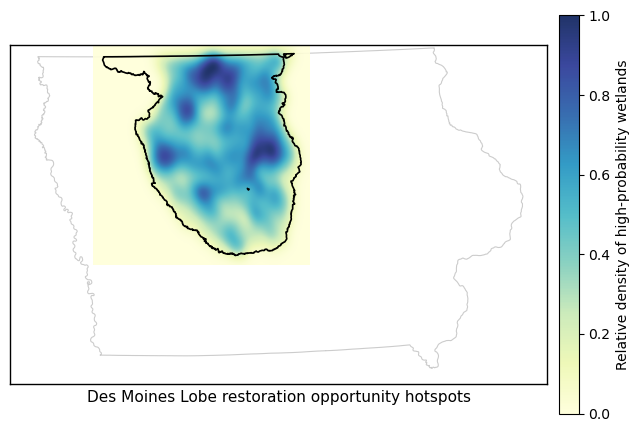

In [4]:
#!/usr/bin/env python3
# uai_highprob_kde_map_context.py
#
# Kernel-density “blueprint” map of high-priority restoration wetlands
# with geographic context:
#   - Des Moines Lobe boundary (provided shapefile)
#   - Iowa state outline (from US states shapefile)
#
# Author: Kimberly Van Meter

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands GeoPackage (already in EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide format)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

# Des Moines Lobe boundary (5070)
DML_BOUNDARY_SHP = PROJECT_ROOT / "DML_2023" / "Shapefiles" / \
    "dml_boundaries_5070.shp"

# US states shapefile (likely geographic; we'll filter to Iowa and reproject)
STATES_SHP = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "cb_2018_us_state_500k/cb_2018_us_state_500k.shp"

# Output figures
OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_context.png"
OUT_JPG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_context.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the per-wetland CSV

# Column with P(UAI > 0) in the wide CSV
PROB_COL = "p_gt_0.000"

# High-priority threshold
HIGH_PROB_THRESH = 0.75

# KDE grid resolution
NX = 400
NY = 400

# Bandwidth multiplier for KDE (1.0 = default, >1 smoother, <1 sharper)
BANDWIDTH_MULT = 0.8

# Colormap for heatmap
CMAP = "YlGnBu"


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # 1. Read wetland polygons (full historical wetland layer)
    print(f"[INFO] Reading wetlands GeoPackage:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GeoPackage. "
            f"Available columns: {list(gdf.columns)}"
        )

    print(f"[INFO] Wetland polygons loaded: {len(gdf)} features.")
    print(f"[INFO] Wetlands CRS: {gdf.crs}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities (wide):\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability rows (wide): {len(prob_df)}")

    # 3. Merge GPKG with probabilities: Index (GPKG) ↔ label (CSV)
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )
    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    if merged.empty:
        raise ValueError(
            "Merge produced zero rows. Check ID_COL_GPKG / ID_COL_CSV and inputs."
        )

    # 4. Filter to high-priority wetlands
    high = merged[merged[PROB_COL] > HIGH_PROB_THRESH].copy()
    n_high = len(high)
    n_total = len(merged)
    if n_high == 0:
        raise ValueError(
            f"No wetlands found with {PROB_COL} > {HIGH_PROB_THRESH}. "
            "Check thresholds and data."
        )

    pct_high = 100.0 * n_high / n_total
    print(
        f"[INFO] High-priority wetlands (P(UAI > 0) > {HIGH_PROB_THRESH}): "
        f"{n_high} of {n_total} ({pct_high:.1f}%)."
    )

    # 5. Ensure projected CRS (EPSG:5070)
    target_crs = "EPSG:5070"
    if merged.crs is None:
        print("[WARN] Wetlands GPKG has no CRS; assuming EPSG:5070.")
        merged.set_crs(epsg=5070, inplace=True)
        high.set_crs(epsg=5070, inplace=True)

    if str(merged.crs) != target_crs:
        print(f"[INFO] Reprojecting wetlands to {target_crs} for KDE.")
        merged_proj = merged.to_crs(target_crs)
        high_proj = high.to_crs(target_crs)
    else:
        merged_proj = merged
        high_proj = high

    # 6. Read Des Moines Lobe boundary (already 5070)
    print(f"[INFO] Reading DML boundary:\n  {DML_BOUNDARY_SHP}")
    dml = gpd.read_file(DML_BOUNDARY_SHP)
    if dml.crs is None:
        dml = dml.set_crs(epsg=5070)
    elif str(dml.crs) != target_crs:
        dml = dml.to_crs(target_crs)

    # 7. Read US states and extract Iowa
    if STATES_SHP.exists():
        print(f"[INFO] Reading US states shapefile:\n  {STATES_SHP}")
        states = gpd.read_file(STATES_SHP)
        # Guess column for state name
        name_col = "NAME" if "NAME" in states.columns else None
        if name_col is None:
            print("[WARN] Could not find 'NAME' column in states shapefile; "
                  "plotting all states as context.")
            iowa = states
        else:
            iowa = states[states[name_col] == "Iowa"].copy()

        if iowa.crs is None:
            iowa = iowa.set_crs(epsg=4269)  # common for Census; adjust if needed
        # Reproject Iowa to 5070
        iowa = iowa.to_crs(target_crs)
    else:
        print(f"[WARN] States shapefile not found at {STATES_SHP}. Skipping.")
        iowa = None

    # 8. Extract centroids of high-priority wetlands
    centroids = high_proj.geometry.centroid
    xs = centroids.x.values
    ys = centroids.y.values

    # 9. Build KDE
    print("[INFO] Computing 2D Gaussian KDE…")
    xy = np.vstack([xs, ys])
    kde = gaussian_kde(xy)
    kde.set_bandwidth(kde.factor * BANDWIDTH_MULT)

    # 10. Define grid over study area (slightly padded DML extent)
    padding = 10000  # 10 km margin
    xmin, ymin, xmax, ymax = (
        dml.total_bounds[0] - padding,
        dml.total_bounds[1] - padding,
        dml.total_bounds[2] + padding,
        dml.total_bounds[3] + padding,
    )

    xgrid = np.linspace(xmin, xmax, NX)
    ygrid = np.linspace(ymin, ymax, NY)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    print("[INFO] Evaluating KDE on grid…")
    Z = np.reshape(kde(positions), X.shape)

    # Normalize for plotting (0–1)
    Z_norm = Z / Z.max()

    # 11. Plot with context
    print("[INFO] Plotting KDE heatmap with DML + Iowa context.")
    fig, ax = plt.subplots(figsize=(6.5, 7.0))

    # Iowa boundary in light gray
    if iowa is not None:
        iowa.boundary.plot(
            ax=ax, color="0.8", linewidth=0.8, zorder=1
        )

    # Heatmap
    im = ax.imshow(
        Z_norm,
        origin="lower",
        cmap=CMAP,
        extent=[xmin, xmax, ymin, ymax],
        interpolation="bilinear",
        alpha=0.9,
        zorder=2,
    )

    # Des Moines Lobe outline on top
    dml.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2,
        zorder=3,
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("Des Moines Lobe restoration opportunity hotspots", fontsize=11)

    # Full bounding box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Relative density of high-probability wetlands", fontsize=10)

    plt.tight_layout()
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands GeoPackage:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386 features.
[INFO] Wetlands CRS: EPSG:5070
[INFO] Reading per-wetland probabilities (wide):
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability rows (wide): 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] High-priority wetlands (P(UAI > 0) > 0.75): 24245 of 135204 (17.9%).
[INFO] Reading DML boundary:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2023/Shapefiles/dml_boundaries_5070.shp
[INFO] Reading US states shapefile:
  /Us

/var/folders/pj/5lhj90zn5qbgb2hy1qpqpnmh0000gn/T/ipykernel_51283/3516607963.py:238: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  dml_union = dml.geometry.unary_union
/var/folders/pj/5lhj90zn5qbgb2hy1qpqpnmh0000gn/T/ipykernel_51283/3516607963.py:260: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(CMAP).copy()


[INFO] Plotting KDE heatmap with DML + Iowa context.
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_highProb_KDE_blueprint_context.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_highProb_KDE_blueprint_context.jpg


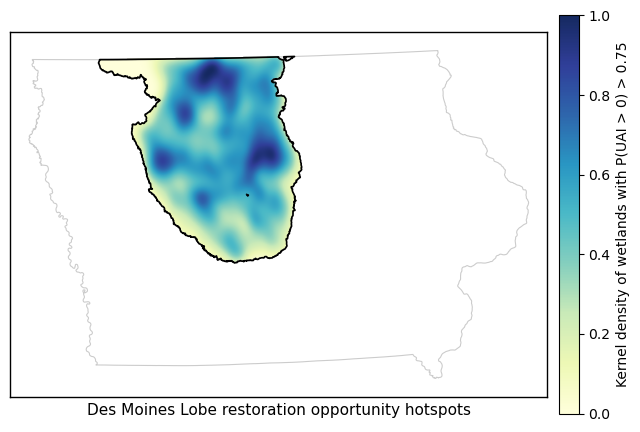

In [6]:
#!/usr/bin/env python3
# uai_highprob_kde_blueprint.py
#
# Kernel-density “blueprint” map of high-priority restoration wetlands
# with geographic context:
#   - Des Moines Lobe boundary (5070 shapefile)
#   - Iowa state outline (from US states shapefile)
#   - KDE of wetlands with P(UAI > 0) > HIGH_PROB_THRESH
#
# Author: Kimberly Van Meter

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from scipy.stats import gaussian_kde
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands GeoPackage (already in EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide format)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

# Des Moines Lobe boundary (5070)
DML_BOUNDARY_SHP = PROJECT_ROOT / "DML_2023" / "Shapefiles" / \
    "dml_boundaries_5070.shp"

# US states shapefile (we will filter to Iowa and reproject to 5070)
STATES_SHP = Path(os.environ.get("DML_GIS_DATA_ROOT", "./gis_data")) / "cb_2018_us_state_500k/cb_2018_us_state_500k.shp"

# Output figures
OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_context.png"
OUT_JPG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_context.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the per-wetland CSV

# Column with P(UAI > 0) in the wide CSV
PROB_COL = "p_gt_0.000"

# High-priority threshold
HIGH_PROB_THRESH = 0.75

# KDE grid resolution
NX = 400
NY = 400

# Bandwidth multiplier for KDE (1.0 = default, >1 smoother, <1 sharper)
BANDWIDTH_MULT = 0.8

# Colormap for heatmap
CMAP = "YlGnBu"

# Target CRS
TARGET_CRS = "EPSG:5070"


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # --------------------------------------------------------
    # 1. Read wetland polygons
    # --------------------------------------------------------
    print(f"[INFO] Reading wetlands GeoPackage:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GeoPackage. "
            f"Available columns: {list(gdf.columns)}"
        )

    print(f"[INFO] Wetland polygons loaded: {len(gdf)} features.")
    print(f"[INFO] Wetlands CRS: {gdf.crs}")

    # --------------------------------------------------------
    # 2. Read per-wetland probabilities (wide)
    # --------------------------------------------------------
    print(f"[INFO] Reading per-wetland probabilities (wide):\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability rows (wide): {len(prob_df)}")

    # --------------------------------------------------------
    # 3. Merge GPKG with probabilities: Index (GPKG) ↔ label (CSV)
    # --------------------------------------------------------
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )
    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    if merged.empty:
        raise ValueError(
            "Merge produced zero rows. Check ID_COL_GPKG / ID_COL_CSV and inputs."
        )

    # --------------------------------------------------------
    # 4. Filter to high-priority wetlands
    # --------------------------------------------------------
    high = merged[merged[PROB_COL] > HIGH_PROB_THRESH].copy()
    n_high = len(high)
    n_total = len(merged)
    if n_high == 0:
        raise ValueError(
            f"No wetlands found with {PROB_COL} > {HIGH_PROB_THRESH}. "
            "Check thresholds and data."
        )

    pct_high = 100.0 * n_high / n_total
    print(
        f"[INFO] High-priority wetlands (P(UAI > 0) > {HIGH_PROB_THRESH}): "
        f"{n_high} of {n_total} ({pct_high:.1f}%)."
    )

    # --------------------------------------------------------
    # 5. Ensure projected CRS (EPSG:5070)
    # --------------------------------------------------------
    if merged.crs is None:
        print("[WARN] Wetlands GPKG has no CRS; assuming EPSG:5070.")
        merged.set_crs(epsg=5070, inplace=True)
        high.set_crs(epsg=5070, inplace=True)

    if str(merged.crs) != TARGET_CRS:
        print(f"[INFO] Reprojecting wetlands to {TARGET_CRS} for KDE.")
        merged_proj = merged.to_crs(TARGET_CRS)
        high_proj = high.to_crs(TARGET_CRS)
    else:
        merged_proj = merged
        high_proj = high

    # --------------------------------------------------------
    # 6. Read Des Moines Lobe boundary (already 5070)
    # --------------------------------------------------------
    print(f"[INFO] Reading DML boundary:\n  {DML_BOUNDARY_SHP}")
    dml = gpd.read_file(DML_BOUNDARY_SHP)
    if dml.crs is None:
        dml = dml.set_crs(epsg=5070)
    elif str(dml.crs) != TARGET_CRS:
        dml = dml.to_crs(TARGET_CRS)

    # --------------------------------------------------------
    # 7. Read US states and extract Iowa
    # --------------------------------------------------------
    if STATES_SHP.exists():
        print(f"[INFO] Reading US states shapefile:\n  {STATES_SHP}")
        states = gpd.read_file(STATES_SHP)

        name_col = "NAME" if "NAME" in states.columns else None
        if name_col is None:
            print("[WARN] Could not find 'NAME' column in states shapefile; "
                  "plotting all states as context.")
            iowa = states
        else:
            iowa = states[states[name_col] == "Iowa"].copy()

        if iowa.crs is None:
            # Census shapefiles are usually in EPSG:4269 or 4326
            iowa = iowa.set_crs(epsg=4269)
        iowa = iowa.to_crs(TARGET_CRS)
    else:
        print(f"[WARN] States shapefile not found at {STATES_SHP}. Skipping.")
        iowa = None

    # --------------------------------------------------------
    # 8. Extract centroids of high-priority wetlands
    # --------------------------------------------------------
    centroids = high_proj.geometry.centroid
    xs = centroids.x.values
    ys = centroids.y.values

    # --------------------------------------------------------
    # 9. Build KDE
    # --------------------------------------------------------
    print("[INFO] Computing 2D Gaussian KDE…")
    xy = np.vstack([xs, ys])
    kde = gaussian_kde(xy)
    kde.set_bandwidth(kde.factor * BANDWIDTH_MULT)

    # --------------------------------------------------------
    # 10. Define KDE grid over DML extent (with small padding)
    # --------------------------------------------------------
    padding = 10000  # 10 km margin
    dml_bounds = dml.total_bounds  # [xmin, ymin, xmax, ymax]
    xmin, ymin, xmax, ymax = (
        dml_bounds[0] - padding,
        dml_bounds[1] - padding,
        dml_bounds[2] + padding,
        dml_bounds[3] + padding,
    )

    xgrid = np.linspace(xmin, xmax, NX)
    ygrid = np.linspace(ymin, ymax, NY)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    print("[INFO] Evaluating KDE on grid…")
    Z = np.reshape(kde(positions), X.shape)

    # Normalize for plotting (0–1)
    Z_norm = Z / Z.max()

    # --------------------------------------------------------
    # 11. Build mask: which grid cells fall inside the DML?
    # --------------------------------------------------------
    print("[INFO] Building DML mask for KDE clipping.")
    dml_union = dml.geometry.unary_union

    # If multipolygon, use the full union; Path can handle multiple segments
    # by using the outer boundary of the union.
    if dml_union.geom_type == "MultiPolygon":
        # merge to one outline
        largest = max(dml_union.geoms, key=lambda g: g.area)
        dml_poly = largest
    else:
        dml_poly = dml_union

    xv, yv = dml_poly.exterior.xy
    poly_coords = np.vstack([xv, yv]).T
    poly_path = MplPath(poly_coords)

    points = np.vstack([X.ravel(), Y.ravel()]).T
    inside = poly_path.contains_points(points).reshape(X.shape)

    # Mask Z outside the DML
    Z_masked = np.where(inside, Z_norm, np.nan)

    # Make a copy of the colormap and set NaNs to transparent
    cmap = plt.cm.get_cmap(CMAP).copy()
    cmap.set_bad(alpha=0.0)

    # --------------------------------------------------------
    # 12. Plot with context (Iowa + DML + clipped KDE)
    # --------------------------------------------------------
    print("[INFO] Plotting KDE heatmap with DML + Iowa context.")
    fig, ax = plt.subplots(figsize=(6.5, 7.0))

    # Iowa boundary in light gray
    if iowa is not None:
        iowa.boundary.plot(
            ax=ax, color="0.8", linewidth=0.8, zorder=1
        )
        ixmin, iymin, ixmax, iymax = iowa.total_bounds
        pad = 20000
        ixmin, iymin, ixmax, iymax = ixmin - pad, iymin - pad, ixmax + pad, iymax + pad
    else:
        ixmin, iymin, ixmax, iymax = xmin, ymin, xmax, ymax

    # KDE heatmap, clipped to DML
    im = ax.imshow(
        Z_masked,
        origin="lower",
        cmap=cmap,
        extent=[xmin, xmax, ymin, ymax],
        interpolation="bilinear",
        alpha=0.95,
        zorder=2,
    )

    # Des Moines Lobe outline on top
    dml.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2,
        zorder=3,
    )

    ax.set_aspect("equal")
    ax.set_xlim(ixmin, ixmax)
    ax.set_ylim(iymin, iymax)
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("Des Moines Lobe restoration opportunity hotspots", fontsize=11)

    # Full bounding box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Kernel density of wetlands with P(UAI > 0) > 0.75", fontsize=10)

    plt.tight_layout()
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands GeoPackage:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386 features.
[INFO] Wetlands CRS: EPSG:5070
[INFO] Reading per-wetland probabilities (wide):
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability rows (wide): 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] High-priority wetlands (P(UAI > 0) > 0.75): 24245 of 135204 (17.9%).
[INFO] Reading DML boundary:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2023/Shapefiles/dml_boundaries_5070.shp
[INFO] Computing 2D Gaussian KDE…
[INFO] 

/var/folders/pj/5lhj90zn5qbgb2hy1qpqpnmh0000gn/T/ipykernel_51283/1281017223.py:187: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  dml_union = dml.geometry.unary_union
/var/folders/pj/5lhj90zn5qbgb2hy1qpqpnmh0000gn/T/ipykernel_51283/1281017223.py:204: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(CMAP).copy()


[INFO] Plotting KDE heatmap clipped to DML.
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_highProb_KDE_blueprint_DMLonly.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_highProb_KDE_blueprint_DMLonly.jpg


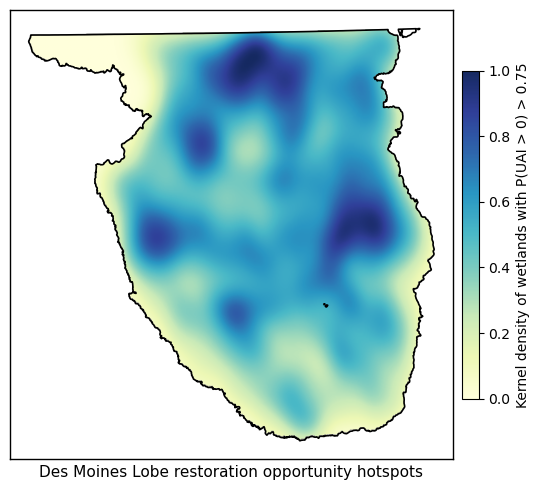

In [7]:
#!/usr/bin/env python3
# uai_highprob_kde_blueprint_DMLonly.py
#
# Kernel-density “blueprint” map of high-priority restoration wetlands
# for the Des Moines Lobe only:
#   - Des Moines Lobe boundary (5070 shapefile)
#   - KDE of wetlands with P(UAI > 0) > HIGH_PROB_THRESH
#   - KDE is clipped to the DML boundary (no rectangular patch)
#
# Author: Kimberly Van Meter

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from scipy.stats import gaussian_kde
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands GeoPackage (already in EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide format)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

# Des Moines Lobe boundary (5070)
DML_BOUNDARY_SHP = PROJECT_ROOT / "DML_2023" / "Shapefiles" / \
    "dml_boundaries_5070.shp"

# Output figures
OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_DMLonly.png"
OUT_JPG = OUT_DIR / "Figure_UAI_highProb_KDE_blueprint_DMLonly.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the per-wetland CSV

# Column with P(UAI > 0) in the wide CSV
PROB_COL = "p_gt_0.000"

# High-priority threshold
HIGH_PROB_THRESH = 0.75

# KDE grid resolution
NX = 400
NY = 400

# Bandwidth multiplier for KDE (1.0 = default, >1 smoother, <1 sharper)
BANDWIDTH_MULT = 0.8

# Colormap for heatmap
CMAP = "YlGnBu"

TARGET_CRS = "EPSG:5070"


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    # 1. Read wetland polygons
    print(f"[INFO] Reading wetlands GeoPackage:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GeoPackage. "
            f"Available columns: {list(gdf.columns)}"
        )

    print(f"[INFO] Wetland polygons loaded: {len(gdf)} features.")
    print(f"[INFO] Wetlands CRS: {gdf.crs}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities (wide):\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability rows (wide): {len(prob_df)}")

    # 3. Merge GPKG with probabilities: Index (GPKG) ↔ label (CSV)
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )
    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    if merged.empty:
        raise ValueError(
            "Merge produced zero rows. Check ID_COL_GPKG / ID_COL_CSV and inputs."
        )

    # 4. Filter to high-priority wetlands
    high = merged[merged[PROB_COL] > HIGH_PROB_THRESH].copy()
    n_high = len(high)
    n_total = len(merged)
    if n_high == 0:
        raise ValueError(
            f"No wetlands found with {PROB_COL} > {HIGH_PROB_THRESH}. "
            "Check thresholds and data."
        )

    pct_high = 100.0 * n_high / n_total
    print(
        f"[INFO] High-priority wetlands (P(UAI > 0) > {HIGH_PROB_THRESH}): "
        f"{n_high} of {n_total} ({pct_high:.1f}%)."
    )

    # 5. Ensure projected CRS (EPSG:5070)
    if merged.crs is None:
        print("[WARN] Wetlands GPKG has no CRS; assuming EPSG:5070.")
        merged.set_crs(epsg=5070, inplace=True)
        high.set_crs(epsg=5070, inplace=True)

    if str(merged.crs) != TARGET_CRS:
        print(f"[INFO] Reprojecting wetlands to {TARGET_CRS} for KDE.")
        merged_proj = merged.to_crs(TARGET_CRS)
        high_proj = high.to_crs(TARGET_CRS)
    else:
        merged_proj = merged
        high_proj = high

    # 6. Read Des Moines Lobe boundary (already 5070)
    print(f"[INFO] Reading DML boundary:\n  {DML_BOUNDARY_SHP}")
    dml = gpd.read_file(DML_BOUNDARY_SHP)
    if dml.crs is None:
        dml = dml.set_crs(epsg=5070)
    elif str(dml.crs) != TARGET_CRS:
        dml = dml.to_crs(TARGET_CRS)

    # 7. Extract centroids of high-priority wetlands
    centroids = high_proj.geometry.centroid
    xs = centroids.x.values
    ys = centroids.y.values

    # 8. Build KDE
    print("[INFO] Computing 2D Gaussian KDE…")
    xy = np.vstack([xs, ys])
    kde = gaussian_kde(xy)
    kde.set_bandwidth(kde.factor * BANDWIDTH_MULT)

    # 9. Define KDE grid over DML extent (with small padding)
    padding = 10000  # 10 km
    dml_bounds = dml.total_bounds  # [xmin, ymin, xmax, ymax]
    xmin, ymin, xmax, ymax = (
        dml_bounds[0] - padding,
        dml_bounds[1] - padding,
        dml_bounds[2] + padding,
        dml_bounds[3] + padding,
    )

    xgrid = np.linspace(xmin, xmax, NX)
    ygrid = np.linspace(ymin, ymax, NY)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    print("[INFO] Evaluating KDE on grid…")
    Z = np.reshape(kde(positions), X.shape)

    # Normalize for plotting (0–1)
    Z_norm = Z / Z.max()

    # 10. Build mask: which grid cells fall inside the DML?
    print("[INFO] Building DML mask for KDE clipping.")
    dml_union = dml.geometry.unary_union

    if dml_union.geom_type == "MultiPolygon":
        # use largest polygon
        dml_poly = max(dml_union.geoms, key=lambda g: g.area)
    else:
        dml_poly = dml_union

    xv, yv = dml_poly.exterior.xy
    poly_coords = np.vstack([xv, yv]).T
    poly_path = MplPath(poly_coords)

    points = np.vstack([X.ravel(), Y.ravel()]).T
    inside = poly_path.contains_points(points).reshape(X.shape)

    Z_masked = np.where(inside, Z_norm, np.nan)

    cmap = plt.cm.get_cmap(CMAP).copy()
    cmap.set_bad(alpha=0.0)  # NaNs transparent

    # 11. Plot DML-only blueprint map
    print("[INFO] Plotting KDE heatmap clipped to DML.")
    fig, ax = plt.subplots(figsize=(5.5, 6.5))

    im = ax.imshow(
        Z_masked,
        origin="lower",
        cmap=cmap,
        extent=[xmin, xmax, ymin, ymax],
        interpolation="bilinear",
        alpha=0.95,
        zorder=2,
    )

    dml.boundary.plot(
        ax=ax,
        color="black",
        linewidth=1.2,
        zorder=3,
    )

    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])

    ax.set_xlabel("Des Moines Lobe restoration opportunity hotspots", fontsize=11)

    # Full bounding box
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(1.0)

    cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    cbar.set_label("Kernel density of wetlands with P(UAI > 0) > 0.75", fontsize=10)

    plt.tight_layout()
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386
[INFO] Reading per-wetland probabilities:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability records: 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] Selected AOIs (centered on high-potential wetlands):
   AOI_4027: (166827.5, 2228367.3)
   AOI_54327: (153335.8, 2255219.3)
   AOI_16608: (101569.3, 2172130.5)


/opt/anaconda3/envs/CBP_random_forest/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_zoomPanels_restorationClasses_satellite.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_zoomPanels_restorationClasses_satellite.jpg


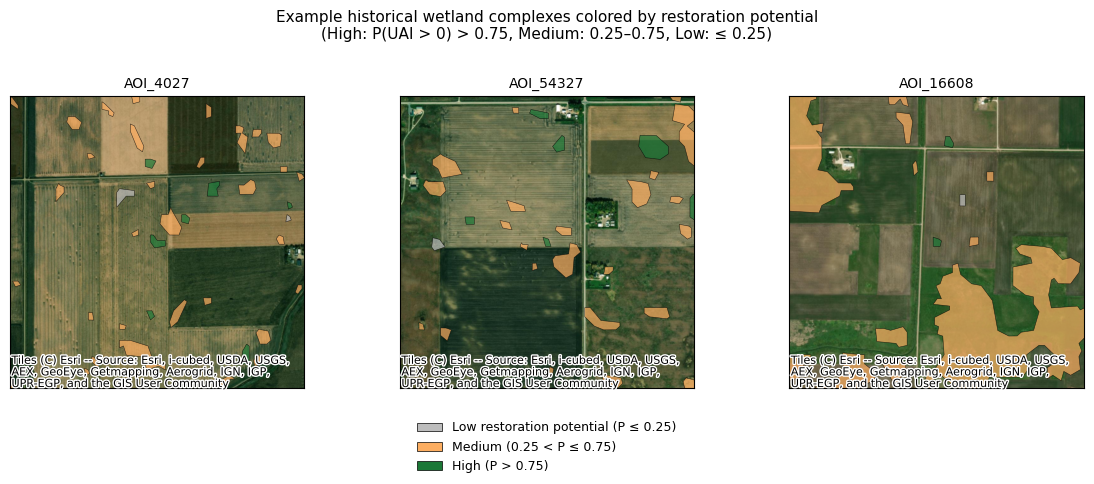

In [9]:
#!/usr/bin/env python3
# uai_zoom_panels_wetland_classes_satellite.py
#
# Create zoomed-in example maps (~1 square mile) showing historical
# wetland polygons color-coded by restoration potential class:
#   High:   P(UAI > 0) > 0.75
#   Medium: 0.25–0.75
#   Low:    <0.25
#
# Each panel is centered on a high-potential wetland and drawn over
# ESRI World Imagery (via contextily).
#
# Author: Kimberly Van Meter

from pathlib import Path
import random

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.patches import Patch

import contextily as ctx  # satellite basemap
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands (EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite.png"
OUT_JPG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the probability CSV

# Probability column (P[UAI > 0])
PROB_COL = "p_gt_0.000"

# Class thresholds
TAU_HIGH  = 0.75   # high potential > 0.75
TAU_LOW   = 0.25   # low potential < 0.25; between is medium

# AOI settings
N_PANELS        = 3         # number of zoom panels to create
AOI_HALF_SIZE_M = 800.0     # half-width of AOI in meters (~1 mile window ≈ 1600 m)

RANDOM_SEED = 42            # for reproducible AOI selection

# Qualitative colors for classes (colorblind-friendly-ish)
COLOR_LOW    = "#bdbdbd"    # light gray
COLOR_MEDIUM = "#fdae61"    # orange
COLOR_HIGH   = "#1b7837"    # teal / green

TARGET_CRS = "EPSG:5070"
WEBMERCATOR_CRS = "EPSG:3857"


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def classify_potential(prob_series: pd.Series) -> pd.Categorical:
    """Classify wetlands into low / medium / high based on P(UAI > 0)."""
    def classify(p):
        if pd.isna(p):
            return "No data"
        if p > TAU_HIGH:
            return "High"
        elif p < TAU_LOW:
            return "Low"
        else:
            return "Medium"

    cats = prob_series.apply(classify)
    return pd.Categorical(
        cats,
        categories=["Low", "Medium", "High", "No data"],
        ordered=True,
    )


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # 1. Read historical wetlands
    print(f"[INFO] Reading wetlands:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GPKG. "
            f"Available columns: {list(gdf.columns)}"
        )

    if gdf.crs is None:
        print("[WARN] Wetlands CRS missing; assuming EPSG:5070.")
        gdf = gdf.set_crs(epsg=5070)

    if str(gdf.crs) != TARGET_CRS:
        print(f"[INFO] Reprojecting wetlands to {TARGET_CRS}.")
        gdf = gdf.to_crs(TARGET_CRS)

    print(f"[INFO] Wetland polygons loaded: {len(gdf)}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities:\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability records: {len(prob_df)}")

    # 3. Merge and classify
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )

    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    merged["restoration_class"] = classify_potential(merged[PROB_COL])

    # 4. Choose AOI centers: randomly pick N_PANELS high-potential wetlands
    high = merged[merged["restoration_class"] == "High"].copy()
    if len(high) < N_PANELS:
        raise ValueError(
            f"Not enough high-potential wetlands ({len(high)}) "
            f"to select {N_PANELS} AOIs."
        )

    high_centroids = high.geometry.centroid
    high["cx"] = high_centroids.x
    high["cy"] = high_centroids.y

    chosen = high.sample(n=N_PANELS, random_state=RANDOM_SEED)
    aois = []
    for _, row in chosen.iterrows():
        cx0 = row["cx"]
        cy0 = row["cy"]
        aois.append(
            dict(
                name=f"AOI_{int(row[ID_COL_GPKG])}",
                cx=cx0,
                cy=cy0,
            )
        )

    print("[INFO] Selected AOIs (centered on high-potential wetlands):")
    for a in aois:
        print(f"   {a['name']}: ({a['cx']:.1f}, {a['cy']:.1f})")

    # 5. Build figure
    fig, axes = plt.subplots(
        1, N_PANELS, figsize=(4.2 * N_PANELS, 4.8), squeeze=False
    )
    axes = axes[0]  # flatten row

    class_to_color = {
        "Low": COLOR_LOW,
        "Medium": COLOR_MEDIUM,
        "High": COLOR_HIGH,
    }

    for ax, aoi in zip(axes, aois):
        cx0 = aoi["cx"]
        cy0 = aoi["cy"]

        # Build AOI bounding box (~1 mile window)
        xmin = cx0 - AOI_HALF_SIZE_M
        xmax = cx0 + AOI_HALF_SIZE_M
        ymin = cy0 - AOI_HALF_SIZE_M
        ymax = cy0 + AOI_HALF_SIZE_M
        aoi_geom = box(xmin, ymin, xmax, ymax)

        # Clip wetlands to AOI
        aoi_gdf = merged[merged.geometry.intersects(aoi_geom)].copy()
        if aoi_gdf.empty:
            ax.set_axis_off()
            ax.text(
                0.5,
                0.5,
                "No wetlands in AOI",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            continue

        # Reproject AOI and wetlands to Web Mercator for basemap
        aoi_polygon_3857 = gpd.GeoSeries([aoi_geom], crs=TARGET_CRS).to_crs(WEBMERCATOR_CRS)
        aoi_gdf_3857 = aoi_gdf.to_crs(WEBMERCATOR_CRS)

        bbox_3857 = aoi_polygon_3857.total_bounds
        x0, y0, x1, y1 = bbox_3857

        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)

        # Basemap: ESRI World Imagery
        ctx.add_basemap(
            ax,
            crs=WEBMERCATOR_CRS,
            source=ctx.providers.Esri.WorldImagery,
        )

        # Plot wetlands by class on top of imagery
        for cls, color in class_to_color.items():
            subset = aoi_gdf_3857[aoi_gdf_3857["restoration_class"] == cls]
            if subset.empty:
                continue
            subset.plot(
                ax=ax,
                facecolor=color,
                edgecolor="black",
                linewidth=0.4,
                alpha=0.7,
            )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(aoi["name"], fontsize=10)

        # Draw panel frame
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

    # 6. Legend (manual, qualitative)
    legend_handles = [
        Patch(facecolor=COLOR_LOW,    edgecolor="black", linewidth=0.5, label="Low"),
        Patch(facecolor=COLOR_MEDIUM, edgecolor="black", linewidth=0.5, label="Medium"),
        Patch(facecolor=COLOR_HIGH,   edgecolor="black", linewidth=0.5, label="High"),
    ]

    fig.legend(
        legend_handles,
        ["Low restoration potential (P ≤ {:.2f})".format(TAU_LOW),
         "Medium ({:.2f} < P ≤ {:.2f})".format(TAU_LOW, TAU_HIGH),
         "High (P > {:.2f})".format(TAU_HIGH)],
        loc="lower center",
        ncol=1,
        frameon=False,
        fontsize=9,
    )

    fig.suptitle(
        "Example historical wetland complexes colored by restoration potential\n"
        f"(High: P(UAI > 0) > {TAU_HIGH:.2f}, "
        f"Medium: {TAU_LOW:.2f}–{TAU_HIGH:.2f}, "
        f"Low: ≤ {TAU_LOW:.2f})",
        fontsize=11,
        y=0.98,
    )

    plt.tight_layout(rect=[0.03, 0.16, 0.97, 0.93])
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386
[INFO] Reading per-wetland probabilities:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability records: 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] Selected AOIs (centered on high-potential wetlands):
   AOI_4027: (166827.5, 2228367.3)
   AOI_54327: (153335.8, 2255219.3)
   AOI_16608: (101569.3, 2172130.5)


/opt/anaconda3/envs/CBP_random_forest/lib/python3.12/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)


[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_zoomPanels_restorationClasses_satellite.png
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_zoomPanels_restorationClasses_satellite.jpg


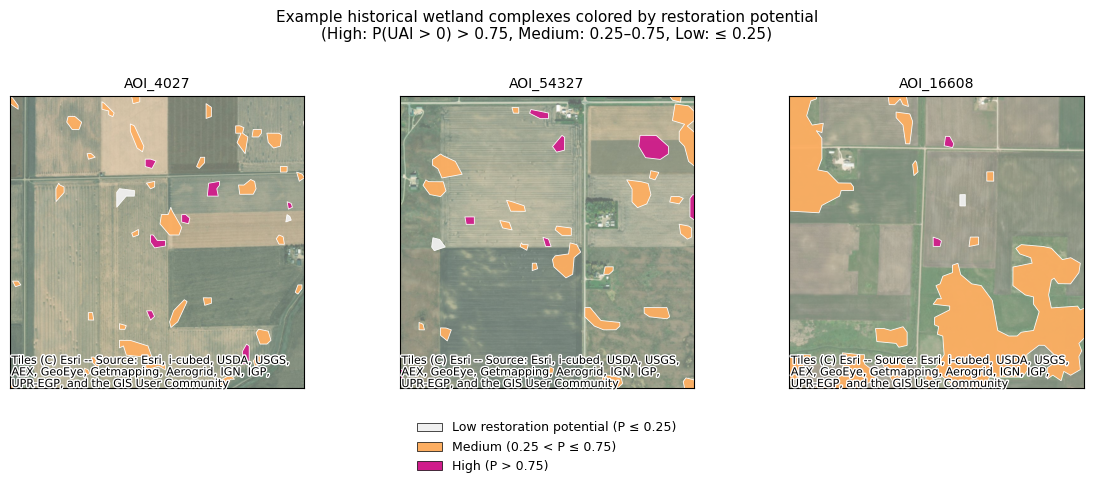

In [10]:
#!/usr/bin/env python3
# uai_zoom_panels_wetland_classes_satellite.py
#
# Zoomed-in example maps (~1 square mile) showing historical
# wetland polygons color-coded by restoration potential class:
#   High:   P(UAI > 0) > 0.75
#   Medium: 0.25–0.75
#   Low:    <0.25
#
# Drawn over ESRI World Imagery (via contextily) with imagery slightly
# dimmed and polygons in high-contrast qualitative colors.
#
# Author: Kimberly Van Meter

from pathlib import Path
import random

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
from matplotlib.patches import Patch

import contextily as ctx  # satellite basemap
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands (EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite.png"
OUT_JPG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the probability CSV

# Probability column (P[UAI > 0])
PROB_COL = "p_gt_0.000"

# Class thresholds
TAU_HIGH  = 0.75   # high potential > 0.75
TAU_LOW   = 0.25   # low potential < 0.25; between is medium

# AOI settings
N_PANELS        = 3         # number of zoom panels to create
AOI_HALF_SIZE_M = 800.0     # half-width of AOI in meters (~1 mile window ≈ 1600 m)

RANDOM_SEED = 42            # for reproducible AOI selection

# Qualitative, high-contrast colors for classes
COLOR_LOW    = "#f0f0f0"    # very light gray
COLOR_MEDIUM = "#fdae61"    # strong orange
COLOR_HIGH   = "#d01c8b"    # magenta/pink that pops on green imagery

TARGET_CRS = "EPSG:5070"
WEBMERCATOR_CRS = "EPSG:3857"


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def classify_potential(prob_series: pd.Series) -> pd.Categorical:
    """Classify wetlands into low / medium / high based on P(UAI > 0)."""
    def classify(p):
        if pd.isna(p):
            return "No data"
        if p > TAU_HIGH:
            return "High"
        elif p < TAU_LOW:
            return "Low"
        else:
            return "Medium"

    cats = prob_series.apply(classify)
    return pd.Categorical(
        cats,
        categories=["Low", "Medium", "High", "No data"],
        ordered=True,
    )


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # 1. Read historical wetlands
    print(f"[INFO] Reading wetlands:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GPKG. "
            f"Available columns: {list(gdf.columns)}"
        )

    if gdf.crs is None:
        print("[WARN] Wetlands CRS missing; assuming EPSG:5070.")
        gdf = gdf.set_crs(epsg=5070)

    if str(gdf.crs) != TARGET_CRS:
        print(f"[INFO] Reprojecting wetlands to {TARGET_CRS}.")
        gdf = gdf.to_crs(TARGET_CRS)

    print(f"[INFO] Wetland polygons loaded: {len(gdf)}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities:\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability records: {len(prob_df)}")

    # 3. Merge and classify
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )

    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    merged["restoration_class"] = classify_potential(merged[PROB_COL])

    # 4. Choose AOI centers: randomly pick N_PANELS high-potential wetlands
    high = merged[merged["restoration_class"] == "High"].copy()
    if len(high) < N_PANELS:
        raise ValueError(
            f"Not enough high-potential wetlands ({len(high)}) "
            f"to select {N_PANELS} AOIs."
        )

    high_centroids = high.geometry.centroid
    high["cx"] = high_centroids.x
    high["cy"] = high_centroids.y

    chosen = high.sample(n=N_PANELS, random_state=RANDOM_SEED)
    aois = []
    for _, row in chosen.iterrows():
        cx0 = row["cx"]
        cy0 = row["cy"]
        aois.append(
            dict(
                name=f"AOI_{int(row[ID_COL_GPKG])}",
                cx=cx0,
                cy=cy0,
            )
        )

    print("[INFO] Selected AOIs (centered on high-potential wetlands):")
    for a in aois:
        print(f"   {a['name']}: ({a['cx']:.1f}, {a['cy']:.1f})")

    # 5. Build figure
    fig, axes = plt.subplots(
        1, N_PANELS, figsize=(4.2 * N_PANELS, 4.8), squeeze=False
    )
    axes = axes[0]  # flatten row

    class_to_color = {
        "Low": COLOR_LOW,
        "Medium": COLOR_MEDIUM,
        "High": COLOR_HIGH,
    }

    for ax, aoi in zip(axes, aois):
        cx0 = aoi["cx"]
        cy0 = aoi["cy"]

        # Build AOI bounding box (~1 mile window)
        xmin = cx0 - AOI_HALF_SIZE_M
        xmax = cx0 + AOI_HALF_SIZE_M
        ymin = cy0 - AOI_HALF_SIZE_M
        ymax = cy0 + AOI_HALF_SIZE_M
        aoi_geom = box(xmin, ymin, xmax, ymax)

        # Clip wetlands to AOI
        aoi_gdf = merged[merged.geometry.intersects(aoi_geom)].copy()
        if aoi_gdf.empty:
            ax.set_axis_off()
            ax.text(
                0.5,
                0.5,
                "No wetlands in AOI",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            continue

        # Reproject AOI and wetlands to Web Mercator for basemap
        aoi_polygon_3857 = gpd.GeoSeries([aoi_geom], crs=TARGET_CRS).to_crs(WEBMERCATOR_CRS)
        aoi_gdf_3857 = aoi_gdf.to_crs(WEBMERCATOR_CRS)

        bbox_3857 = aoi_polygon_3857.total_bounds
        x0, y0, x1, y1 = bbox_3857

        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)

        # Basemap: ESRI World Imagery, slightly dimmed
        ctx.add_basemap(
            ax,
            crs=WEBMERCATOR_CRS,
            source=ctx.providers.Esri.WorldImagery,
            alpha=0.6,  # dim imagery so polygons stand out more
        )

        # Plot wetlands by class on top of imagery
        for cls, color in class_to_color.items():
            subset = aoi_gdf_3857[aoi_gdf_3857["restoration_class"] == cls]
            if subset.empty:
                continue
            subset.plot(
                ax=ax,
                facecolor=color,
                edgecolor="white",   # white edge for contrast
                linewidth=0.6,
                alpha=0.95,          # almost fully opaque
            )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(aoi["name"], fontsize=10)

        # Draw panel frame
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

    # 6. Legend (manual, qualitative)
    legend_handles = [
        Patch(facecolor=COLOR_LOW,    edgecolor="black", linewidth=0.5, label="Low"),
        Patch(facecolor=COLOR_MEDIUM, edgecolor="black", linewidth=0.5, label="Medium"),
        Patch(facecolor=COLOR_HIGH,   edgecolor="black", linewidth=0.5, label="High"),
    ]

    fig.legend(
        legend_handles,
        [
            f"Low restoration potential (P ≤ {TAU_LOW:.2f})",
            f"Medium ({TAU_LOW:.2f} < P ≤ {TAU_HIGH:.2f})",
            f"High (P > {TAU_HIGH:.2f})",
        ],
        loc="lower center",
        ncol=1,
        frameon=False,
        fontsize=9,
    )

    fig.suptitle(
        "Example historical wetland complexes colored by restoration potential\n"
        f"(High: P(UAI > 0) > {TAU_HIGH:.2f}, "
        f"Medium: {TAU_LOW:.2f}–{TAU_HIGH:.2f}, "
        f"Low: ≤ {TAU_LOW:.2f})",
        fontsize=11,
        y=0.98,
    )

    plt.tight_layout(rect=[0.03, 0.16, 0.97, 0.93])
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()


[INFO] Reading wetlands:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/DML_2025/Historical_Wetlands_FILT/Historical_Wetlands_TYLER_max647500m2_5070.gpkg
[INFO] Wetland polygons loaded: 200386
[INFO] Reading per-wetland probabilities:
  /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/UAI_per_wetland_probs_nocrop_wide.csv
[INFO] Probability records: 138534
[INFO] After merge: 135204 wetlands with probabilities.
[INFO] AOIs for panels:
   AOI_high_1: (166827.5, 2228367.3)
   AOI_high_2: (153335.8, 2255219.3)
   AOI_midlat_west: (189618.3, 2112652.8)
[SAVED] /Users/kimberlyvanmeter/Library/CloudStorage/GoogleDrive-vanmeterlab@gmail.com/My Drive/Research/Projects/NASA - UMRB Legacy Wetlands/NDVI_wetlands_figures/Figure_UAI_zoomPanels_restorationClasses_satellite_manualAOI.png
[SAVED] /Users/kimbe

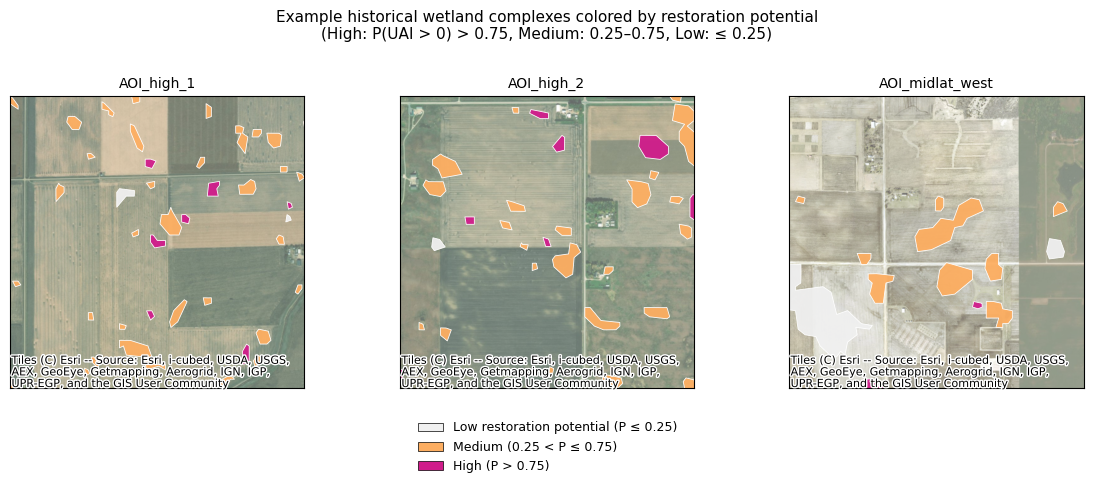

In [11]:
#!/usr/bin/env python3
# uai_zoom_panels_wetland_classes_satellite_manualAOI.py
#
# Zoomed-in example maps (~1 square mile) showing historical
# wetland polygons color-coded by restoration potential class:
#   High:   P(UAI > 0) > 0.75
#   Medium: 0.25–0.75
#   Low:    <0.25
#
# Panels 1–2: centered on random high-potential wetlands.
# Panel 3: centered on a user-specified lon/lat (mid-latitude western
#          region of the NDVI AOI).
#
# Drawn over ESRI World Imagery (via contextily), imagery slightly dimmed,
# polygons in high-contrast qualitative colors.
#
# Author: Kimberly Van Meter

from pathlib import Path
import random

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box, Point
from matplotlib.patches import Patch

import contextily as ctx  # satellite basemap
import os

# ------------------------------------------------------------
# USER SETTINGS
# ------------------------------------------------------------

PROJECT_ROOT = Path(os.environ.get("DML_PROJECT_ROOT", "."))

# Historical wetlands (EPSG:5070)
WETLANDS_GPKG = PROJECT_ROOT / "DML_2025" / "Historical_Wetlands_FILT" / \
    "Historical_Wetlands_TYLER_max647500m2_5070.gpkg"

# Per-wetland probability CSV (no-crop, wide)
PROB_WIDE_CSV = PROJECT_ROOT / "NDVI_wetlands_figures" / \
    "UAI_per_wetland_probs_nocrop_wide.csv"

OUT_DIR = PROJECT_ROOT / "NDVI_wetlands_figures"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PNG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite_manualAOI.png"
OUT_JPG = OUT_DIR / "Figure_UAI_zoomPanels_restorationClasses_satellite_manualAOI.jpg"

# ID columns
ID_COL_GPKG = "Index"   # in the GeoPackage
ID_COL_CSV  = "label"   # in the probability CSV

# Probability column (P[UAI > 0])
PROB_COL = "p_gt_0.000"

# Class thresholds
TAU_HIGH  = 0.75   # high potential > 0.75
TAU_LOW   = 0.25   # low potential < 0.25; between is medium

# AOI settings
N_PANELS        = 3         # total panels
AOI_HALF_SIZE_M = 800.0     # half-width of AOI in meters (~1 mile window ≈ 1600 m)

RANDOM_SEED = 42            # for reproducible random AOIs

# >>>>>> MANUAL AOI CENTER (lon/lat in degrees) <<<<<<
# Approximate mid-latitude western portion of your NDVI AOI;
# tweak these two numbers as needed.
MANUAL_LON = -93.695
MANUAL_LAT = 41.995

# Qualitative, high-contrast colors for classes
COLOR_LOW    = "#f0f0f0"    # very light gray
COLOR_MEDIUM = "#fdae61"    # strong orange
COLOR_HIGH   = "#d01c8b"    # magenta/pink that pops on green imagery

TARGET_CRS = "EPSG:5070"
WEBMERCATOR_CRS = "EPSG:3857"


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def classify_potential(prob_series: pd.Series) -> pd.Categorical:
    """Classify wetlands into low / medium / high based on P(UAI > 0)."""
    def classify(p):
        if pd.isna(p):
            return "No data"
        if p > TAU_HIGH:
            return "High"
        elif p < TAU_LOW:
            return "Low"
        else:
            return "Medium"

    cats = prob_series.apply(classify)
    return pd.Categorical(
        cats,
        categories=["Low", "Medium", "High", "No data"],
        ordered=True,
    )


def lonlat_to_5070(lon: float, lat: float) -> tuple[float, float]:
    """Convert lon/lat (EPSG:4326) to EPSG:5070."""
    pt = gpd.GeoSeries([Point(lon, lat)], crs="EPSG:4326").to_crs(TARGET_CRS)
    geom = pt.geometry.iloc[0]
    return float(geom.x), float(geom.y)


# ------------------------------------------------------------
# MAIN
# ------------------------------------------------------------

def main():
    random.seed(RANDOM_SEED)
    np.random.seed(RANDOM_SEED)

    # 1. Read historical wetlands
    print(f"[INFO] Reading wetlands:\n  {WETLANDS_GPKG}")
    gdf = gpd.read_file(WETLANDS_GPKG)

    if ID_COL_GPKG not in gdf.columns:
        raise KeyError(
            f"ID column '{ID_COL_GPKG}' not found in wetlands GPKG. "
            f"Available columns: {list(gdf.columns)}"
        )

    if gdf.crs is None:
        print("[WARN] Wetlands CRS missing; assuming EPSG:5070.")
        gdf = gdf.set_crs(epsg=5070)

    if str(gdf.crs) != TARGET_CRS:
        print(f"[INFO] Reprojecting wetlands to {TARGET_CRS}.")
        gdf = gdf.to_crs(TARGET_CRS)

    print(f"[INFO] Wetland polygons loaded: {len(gdf)}")

    # 2. Read per-wetland probabilities (wide)
    print(f"[INFO] Reading per-wetland probabilities:\n  {PROB_WIDE_CSV}")
    prob_df = pd.read_csv(PROB_WIDE_CSV)

    required_cols = {ID_COL_CSV, PROB_COL}
    missing = required_cols.difference(prob_df.columns)
    if missing:
        raise KeyError(f"Probability CSV missing required columns: {missing}")

    print(f"[INFO] Probability records: {len(prob_df)}")

    # 3. Merge and classify
    merged = gdf.merge(
        prob_df[[ID_COL_CSV, PROB_COL]],
        left_on=ID_COL_GPKG,
        right_on=ID_COL_CSV,
        how="inner",
    )

    print(f"[INFO] After merge: {len(merged)} wetlands with probabilities.")

    merged["restoration_class"] = classify_potential(merged[PROB_COL])

    # 4. Build AOI list:
    #    - First N_PANELS-1 panels from random high-potential wetlands
    #    - Last panel from manual lon/lat
    high = merged[merged["restoration_class"] == "High"].copy()
    if len(high) < (N_PANELS - 1):
        raise ValueError(
            f"Not enough high-potential wetlands ({len(high)}) "
            f"to select {N_PANELS - 1} random AOIs."
        )

    high_centroids = high.geometry.centroid
    high["cx"] = high_centroids.x
    high["cy"] = high_centroids.y

    chosen = high.sample(n=N_PANELS - 1, random_state=RANDOM_SEED)

    aois: list[dict] = []

    # Random high-potential AOIs
    for k, (_, row) in enumerate(chosen.iterrows(), start=1):
        aois.append(
            dict(
                name=f"AOI_high_{k}",
                cx=float(row["cx"]),
                cy=float(row["cy"]),
            )
        )

    # Manual AOI from lon/lat
    cx_manual, cy_manual = lonlat_to_5070(MANUAL_LON, MANUAL_LAT)
    aois.append(
        dict(
            name="AOI_midlat_west",
            cx=cx_manual,
            cy=cy_manual,
        )
    )

    print("[INFO] AOIs for panels:")
    for a in aois:
        print(f"   {a['name']}: ({a['cx']:.1f}, {a['cy']:.1f})")

    # 5. Build figure
    fig, axes = plt.subplots(
        1, N_PANELS, figsize=(4.2 * N_PANELS, 4.8), squeeze=False
    )
    axes = axes[0]  # flatten row

    class_to_color = {
        "Low": COLOR_LOW,
        "Medium": COLOR_MEDIUM,
        "High": COLOR_HIGH,
    }

    for ax, aoi in zip(axes, aois):
        cx0 = aoi["cx"]
        cy0 = aoi["cy"]

        # Build AOI bounding box (~1 mile window)
        xmin = cx0 - AOI_HALF_SIZE_M
        xmax = cx0 + AOI_HALF_SIZE_M
        ymin = cy0 - AOI_HALF_SIZE_M
        ymax = cy0 + AOI_HALF_SIZE_M
        aoi_geom = box(xmin, ymin, xmax, ymax)

        # Clip wetlands to AOI
        aoi_gdf = merged[merged.geometry.intersects(aoi_geom)].copy()
        if aoi_gdf.empty:
            ax.set_axis_off()
            ax.text(
                0.5,
                0.5,
                "No wetlands in AOI",
                transform=ax.transAxes,
                ha="center",
                va="center",
            )
            continue

        # Reproject AOI and wetlands to Web Mercator for basemap
        aoi_polygon_3857 = gpd.GeoSeries([aoi_geom], crs=TARGET_CRS).to_crs(WEBMERCATOR_CRS)
        aoi_gdf_3857 = aoi_gdf.to_crs(WEBMERCATOR_CRS)

        bbox_3857 = aoi_polygon_3857.total_bounds
        x0, y0, x1, y1 = bbox_3857

        ax.set_xlim(x0, x1)
        ax.set_ylim(y0, y1)

        # Basemap: ESRI World Imagery, slightly dimmed
        ctx.add_basemap(
            ax,
            crs=WEBMERCATOR_CRS,
            source=ctx.providers.Esri.WorldImagery,
            alpha=0.6,
        )

        # Plot wetlands by class on top of imagery
        for cls, color in class_to_color.items():
            subset = aoi_gdf_3857[aoi_gdf_3857["restoration_class"] == cls]
            if subset.empty:
                continue
            subset.plot(
                ax=ax,
                facecolor=color,
                edgecolor="white",
                linewidth=0.6,
                alpha=0.95,
            )

        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

        ax.set_title(aoi["name"], fontsize=10)

        # Draw panel frame
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(0.8)

    # 6. Legend (manual, qualitative)
    legend_handles = [
        Patch(facecolor=COLOR_LOW,    edgecolor="black", linewidth=0.5, label="Low"),
        Patch(facecolor=COLOR_MEDIUM, edgecolor="black", linewidth=0.5, label="Medium"),
        Patch(facecolor=COLOR_HIGH,   edgecolor="black", linewidth=0.5, label="High"),
    ]

    fig.legend(
        legend_handles,
        [
            f"Low restoration potential (P ≤ {TAU_LOW:.2f})",
            f"Medium ({TAU_LOW:.2f} < P ≤ {TAU_HIGH:.2f})",
            f"High (P > {TAU_HIGH:.2f})",
        ],
        loc="lower center",
        ncol=1,
        frameon=False,
        fontsize=9,
    )

    fig.suptitle(
        "Example historical wetland complexes colored by restoration potential\n"
        f"(High: P(UAI > 0) > {TAU_HIGH:.2f}, "
        f"Medium: {TAU_LOW:.2f}–{TAU_HIGH:.2f}, "
        f"Low: ≤ {TAU_LOW:.2f})",
        fontsize=11,
        y=0.98,
    )

    plt.tight_layout(rect=[0.03, 0.16, 0.97, 0.93])
    fig.savefig(OUT_PNG, dpi=300)
    fig.savefig(OUT_JPG, dpi=300)
    print(f"[SAVED] {OUT_PNG}")
    print(f"[SAVED] {OUT_JPG}")


if __name__ == "__main__":
    main()
